# Carga inicial del dataset de tweets


In [2]:
import pandas as pd

df = pd.read_csv("../data/tweets.csv")
print(df.shape)

(52542, 10)


In [3]:
print(list(df.columns))
print()
print(df.dtypes)

['author', 'content', 'country', 'date_time', 'id', 'language', 'latitude', 'longitude', 'number_of_likes', 'number_of_shares']

author                  str
content                 str
country                 str
date_time               str
id                  float64
language                str
latitude            float64
longitude           float64
number_of_likes       int64
number_of_shares      int64
dtype: object


In [4]:
display(df.head())
display(df.tail())

,author,content,country,date_time,id,language,latitude,longitude,number_of_likes,number_of_shares
0,katyperry,Is history repeating itself...?#DONTNORMALIZEH...,NaN,12/01/2017 19:52,8.196330e+17,en,NaN,NaN,7900,3472
1,katyperry,@barackobama Thank you for your incredible gra...,NaN,11/01/2017 08:38,8.191010e+17,en,NaN,NaN,3689,1380
2,katyperry,Life goals. https://t.co/XIn1qKMKQl,NaN,11/01/2017 02:52,8.190140e+17,en,NaN,NaN,10341,2387
3,katyperry,Me right now 🙏🏻 https://t.co/gW55C1wrwd,NaN,11/01/2017 02:44,8.190120e+17,en,NaN,NaN,10774,2458
4,katyperry,SISTERS ARE DOIN' IT FOR THEMSELVES! 🙌🏻💪🏻❤️ ht...,NaN,10/01/2017 05:22,8.186890e+17,en,NaN,NaN,17620,4655


,author,content,country,date_time,id,language,latitude,longitude,number_of_likes,number_of_shares
52537,ddlovato,Life couldn't be better right now. 😊,NaN,06/01/2015 23:10,5.526030e+17,en,NaN,NaN,32799,23796
52538,ddlovato,First Monday back in action. I'd say 21.6 mile...,NaN,06/01/2015 02:17,5.522880e+17,en,NaN,NaN,21709,12511
52539,ddlovato,"Crime shows, buddy, snuggles = the perfect Sun...",NaN,05/01/2015 03:42,5.519470e+17,en,NaN,NaN,25269,15583
52540,ddlovato,❄️ http://t.co/sHCFdPpGPa,NaN,05/01/2015 00:06,5.518920e+17,und,NaN,NaN,15985,10456
52541,ddlovato,❤️❄️✈️ http://t.co/ixmB5lv17Z,NaN,05/01/2015 00:02,5.518910e+17,und,NaN,NaN,16193,10822


In [5]:
print("Valores nulos por columna:")
df.isna().sum()

Valores nulos por columna:


author                  0
content                 0
country             52506
date_time               0
id                      0
language                0
latitude            52541
longitude           52541
number_of_likes         0
number_of_shares        0
dtype: int64

In [6]:
print("Valores únicos por columna:")
df.nunique()

Valores únicos por columna:


author                 20
content             52425
country                 2
date_time           49590
id                  43641
language               32
latitude                1
longitude               1
number_of_likes     19572
number_of_shares    14599
dtype: int64

In [7]:
df.describe()

,id,latitude,longitude,number_of_likes,number_of_shares
count,5.254200e+04,1.000000,1.000000,52542.000000,52542.000000
mean,5.741141e+17,37.776973,-122.416523,9637.838339,5386.880857
std,2.009723e+17,NaN,NaN,18759.083482,11517.259484
min,6.789717e+09,37.776973,-122.416523,0.000000,0.000000
25%,4.485852e+17,37.776973,-122.416523,916.000000,378.000000
50%,6.337935e+17,37.776973,-122.416523,2595.500000,1266.000000
75%,7.336588e+17,37.776973,-122.416523,10300.750000,5205.000000
max,8.237200e+17,37.776973,-122.416523,429159.000000,219062.000000


In [8]:
print("Autores con más tweets:")
print(df["author"].value_counts().head(10))
print()
print("Idiomas:")
print(df["language"].value_counts().head(10))

Autores con más tweets:
author
TheEllenShow     3147
jimmyfallon      3123
ArianaGrande     3104
YouTube          3077
KimKardashian    2939
katyperry        2924
selenagomez      2913
rihanna          2877
BarackObama      2863
britneyspears    2776
Name: count, dtype: int64

Idiomas:
language
en     46934
und     3242
es      1372
pt       180
fr       118
tl       113
in       108
et        61
nl        51
it        50
Name: count, dtype: int64


## Limpieza y preprocesamiento
1. Duplicados (por autor + contenido + fecha).
2. Tipos: `date_time` a datetime, numericas y texto.
3. Nulos: se quita `content`/fecha vacios; `country`/`language` -> `unknown`; likes/shares -> 0.
4. Texto: se extraen menciones, hashtags y URLs; `content_clean` + metricas.
5. Fecha: `year`, `month`, `hour`, `weekday`, `engagement`.
6. Se exporta `data/tweets_clean.csv`.

In [9]:
import re

df_clean = df.copy()

# Duplicados 
df_clean = df_clean.drop_duplicates()
df_clean = df_clean.drop_duplicates(subset=["author", "content", "date_time"])
print("Filas:", len(df), "->", len(df_clean))

Filas: 52542 -> 52542


In [10]:
# Tipos de datos
df_clean["date_time"] = pd.to_datetime(
    df_clean["date_time"], format="%d/%m/%Y %H:%M", errors="coerce"
)
for c in ["latitude", "longitude", "number_of_likes", "number_of_shares"]:
    df_clean[c] = pd.to_numeric(df_clean[c], errors="coerce")
for c in ["author", "content", "language", "country"]:
    df_clean[c] = df_clean[c].astype("string").str.strip()

df_clean.dtypes

author                      string
content                     string
country                     string
date_time           datetime64[us]
id                         float64
language                    string
latitude                   float64
longitude                  float64
number_of_likes              int64
number_of_shares             int64
dtype: object

In [11]:
# Nulos
df_clean = df_clean[df_clean["content"].notna() & (df_clean["content"] != "")]
df_clean = df_clean[df_clean["date_time"].notna()]
df_clean["country"] = df_clean["country"].fillna("unknown")
df_clean["language"] = df_clean["language"].fillna("unknown")
df_clean["number_of_likes"] = df_clean["number_of_likes"].fillna(0).astype("int64")
df_clean["number_of_shares"] = df_clean["number_of_shares"].fillna(0).astype("int64")

print(df_clean.isna().sum())
print("Filas:", len(df_clean))

author                  0
content                 0
country                 0
date_time               0
id                      0
language                0
latitude            52541
longitude           52541
number_of_likes         0
number_of_shares        0
dtype: int64
Filas: 52542


In [12]:
# Texto: extraer entidades y limpiar
URL_RE = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE = re.compile(r"@(\w+)")
HASHTAG_RE = re.compile(r"#(\w+)")

df_clean["mentions"] = df_clean["content"].str.findall(MENTION_RE)
df_clean["hashtags"] = df_clean["content"].str.findall(HASHTAG_RE)
df_clean["has_url"] = df_clean["content"].str.contains(URL_RE)

def limpiar(t):
    t = URL_RE.sub("", t)
    t = MENTION_RE.sub("", t)
    t = HASHTAG_RE.sub(r"\1", t)          
    t = t.replace("&amp;", "&").replace("&lt;", "<").replace("&gt;", ">")
    return re.sub(r"\s+", " ", t).strip().lower()

df_clean["content_clean"] = df_clean["content"].apply(limpiar)
df_clean = df_clean[df_clean["content_clean"] != ""]

df_clean["text_length"] = df_clean["content_clean"].str.len()
df_clean["word_count"] = df_clean["content_clean"].str.split().str.len()
df_clean["n_hashtags"] = df_clean["hashtags"].str.len()

df_clean[["content", "content_clean", "hashtags", "has_url"]].head()

,content,content_clean,hashtags,has_url
0,Is history repeating itself...?#DONTNORMALIZEH...,is history repeating itself...?dontnormalizehate,[DONTNORMALIZEHATE],True
1,@barackobama Thank you for your incredible gra...,thank you for your incredible grace in leaders...,[],True
2,Life goals. https://t.co/XIn1qKMKQl,life goals.,[],True
3,Me right now 🙏🏻 https://t.co/gW55C1wrwd,me right now 🙏🏻,[],True
4,SISTERS ARE DOIN' IT FOR THEMSELVES! 🙌🏻💪🏻❤️ ht...,sisters are doin' it for themselves! 🙌🏻💪🏻❤️,[],True


In [13]:
# Variables temporales + engagement
df_clean["year"] = df_clean["date_time"].dt.year
df_clean["month"] = df_clean["date_time"].dt.month
df_clean["hour"] = df_clean["date_time"].dt.hour
df_clean["weekday"] = df_clean["date_time"].dt.day_name()
df_clean["engagement"] = df_clean["number_of_likes"] + df_clean["number_of_shares"]

df_clean = df_clean.sort_values("date_time").reset_index(drop=True)
print("Shape final:", df_clean.shape)
df_clean.head()

Shape final: (52257, 22)


,author,content,country,date_time,id,language,latitude,longitude,number_of_likes,number_of_shares,...,has_url,content_clean,text_length,word_count,n_hashtags,year,month,hour,weekday,engagement
0,Twitter,Twitter's DNS records were temporarily comprom...,unknown,2009-12-18 07:36:00,6.789717e+09,en,NaN,NaN,73,504,...,False,twitter's dns records were temporarily comprom...,118,18,0,2009,12,7,Friday,577
1,Twitter,Update on the DNS issue of last night: http://...,unknown,2009-12-18 21:59:00,6.809736e+09,en,NaN,NaN,55,107,...,True,update on the dns issue of last night:,38,8,0,2009,12,21,Friday,162
2,Twitter,Look! A shiny new blog design. http://blog.twi...,unknown,2009-12-22 18:39:00,6.937397e+09,en,NaN,NaN,53,72,...,True,look! a shiny new blog design. thanks !,39,8,0,2009,12,18,Tuesday,125
3,Twitter,"If you use a Palm Pre, here are some reviews o...",unknown,2009-12-23 17:29:00,6.970825e+09,en,NaN,NaN,40,41,...,True,"if you use a palm pre, here are some reviews o...",95,18,1,2009,12,17,Wednesday,81
4,Twitter,Twitter acquires GeoAPI—location awareness to ...,unknown,2009-12-23 22:38:00,6.979006e+09,en,NaN,NaN,67,104,...,True,twitter acquires geoapi—location awareness to ...,61,7,0,2009,12,22,Wednesday,171


In [14]:
# Guardar CSV limpio
export = df_clean.copy()
export["mentions"] = export["mentions"].str.join("|")
export["hashtags"] = export["hashtags"].str.join("|")

export.to_csv("../data/tweets_clean.csv", index=False, encoding="utf-8")
print("Guardado ../data/tweets_clean.csv", export.shape)

Guardado ../data/tweets_clean.csv (52257, 22)


## EDA

### Tabla resumen de tweets parseados

In [15]:
resumen_cols = [
    "date_time", "author", "content", "content_clean",
    "mentions", "hashtags", "number_of_likes", "number_of_shares",
]
tabla_resumen = df_clean[resumen_cols].copy()
tabla_resumen["mentions"] = tabla_resumen["mentions"].apply(lambda m: ", ".join(m))
tabla_resumen["hashtags"] = tabla_resumen["hashtags"].apply(lambda h: ", ".join(h))
tabla_resumen = tabla_resumen.rename(columns={
    "date_time": "tiempo_de_publicado",
    "author": "autor",
    "content": "tweet",
    "content_clean": "tweet_text_clean",
    "number_of_likes": "likes",
    "number_of_shares": "shares",
})

tabla_resumen.head(10)

,tiempo_de_publicado,autor,tweet,tweet_text_clean,mentions,hashtags,likes,shares
0,2009-12-18 07:36:00,Twitter,Twitter's DNS records were temporarily comprom...,twitter's dns records were temporarily comprom...,,,73,504
1,2009-12-18 21:59:00,Twitter,Update on the DNS issue of last night: http://...,update on the dns issue of last night:,,,55,107
2,2009-12-22 18:39:00,Twitter,Look! A shiny new blog design. http://blog.twi...,look! a shiny new blog design. thanks !,vl,,53,72
3,2009-12-23 17:29:00,Twitter,"If you use a Palm Pre, here are some reviews o...","if you use a palm pre, here are some reviews o...",,appwednesday,40,41
4,2009-12-23 22:38:00,Twitter,Twitter acquires GeoAPI—location awareness to ...,twitter acquires geoapi—location awareness to ...,,,67,104
5,2009-12-28 00:43:00,Twitter,"Sunday Times: ""Why we can never rest: a year i...","sunday times: ""why we can never rest: a year i...",,,121,133
6,2009-12-29 23:54:00,Twitter,Did you know about all of the accounts we have...,did you know about all of the accounts we have...,,,235,54
7,2009-12-30 00:08:00,Twitter,Here's a link to that same list where you won'...,here's a link to that same list where you won'...,,,142,34
8,2009-12-30 19:45:00,Twitter,People are loving @twidroid for Android phones...,people are loving for android phones. do you l...,twidroid,appwednesday,37,46
9,2009-12-30 23:56:00,Twitter,Time is of the essence on New Year's Eve. Foll...,time is of the essence on new year's eve. foll...,timessquarenyc,,53,99


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

n_tweets = len(df_clean)
n_usuarios = df_clean["author"].nunique()

print(f"Total de tweets: {n_tweets}")
print(f"Usuarios unicos: {n_usuarios}")
print(f"Rango de fechas: {df_clean['date_time'].min()} a {df_clean['date_time'].max()}")

Total de tweets: 52257
Usuarios unicos: 20
Rango de fechas: 2009-12-18 07:36:00 a 2017-01-24 02:30:00


### Menciones y hashtags

In [17]:
mentions_all = df_clean["mentions"].explode().dropna()
hashtags_all = df_clean["hashtags"].explode().dropna()

print(f"Total de menciones: {len(mentions_all)}")
print(f"Total de hashtags: {len(hashtags_all)}")

top_mentions = mentions_all.str.lower().value_counts().head(10)
top_hashtags = hashtags_all.str.lower().value_counts().head(10)

print("\nTop 10 menciones:")
print(top_mentions)
print("\nTop 10 hashtags:")
print(top_hashtags)

Total de menciones: 27019
Total de hashtags: 25818

Top 10 menciones:
mentions
jtimberlake     541
katyperry       318
jimmyfallon     254
cristiano       200
rihanna         175
nbcthevoice     148
vevo            139
itunesmusic     133
ofa             117
theellenshow    106
Name: count, dtype: int64

Top 10 hashtags:
hashtags
fallontonight    1079
actonclimate      277
tbt               234
dailyfluff        215
lovetwitter       166
ts1989            165
1                 162
fallonmono        152
confident         149
doyourjob         147
Name: count, dtype: int64


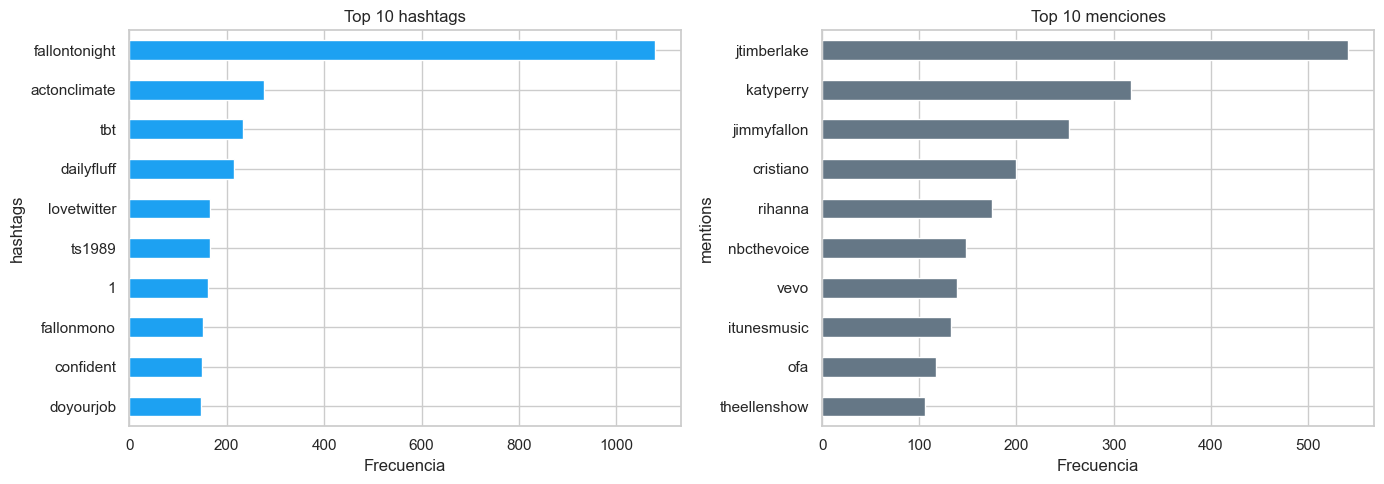

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_hashtags.iloc[::-1].plot(kind="barh", ax=axes[0], color="#1DA1F2")
axes[0].set_title("Top 10 hashtags")
axes[0].set_xlabel("Frecuencia")

top_mentions.iloc[::-1].plot(kind="barh", ax=axes[1], color="#657786")
axes[1].set_title("Top 10 menciones")
axes[1].set_xlabel("Frecuencia")

plt.tight_layout()
plt.show()

### Autores y actividad en el tiempo

Top 10 autores por numero de tweets:
author
TheEllenShow     3147
jimmyfallon      3120
ArianaGrande     3081
YouTube          3073
KimKardashian    2926
katyperry        2908
selenagomez      2868
BarackObama      2863
rihanna          2852
britneyspears    2772
Name: count, dtype: Int64


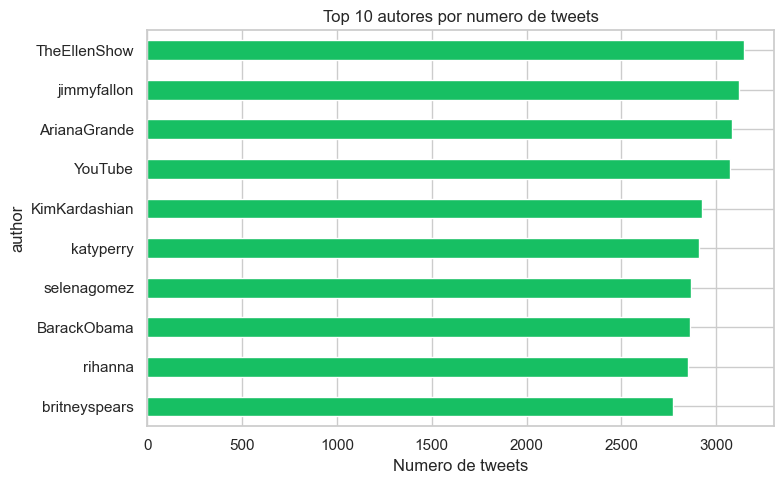

In [19]:
top_autores = df_clean["author"].value_counts().head(10)
print("Top 10 autores por numero de tweets:")
print(top_autores)

fig, ax = plt.subplots(figsize=(8, 5))
top_autores.iloc[::-1].plot(kind="barh", ax=ax, color="#17BF63")
ax.set_title("Top 10 autores por numero de tweets")
ax.set_xlabel("Numero de tweets")
plt.tight_layout()
plt.show()

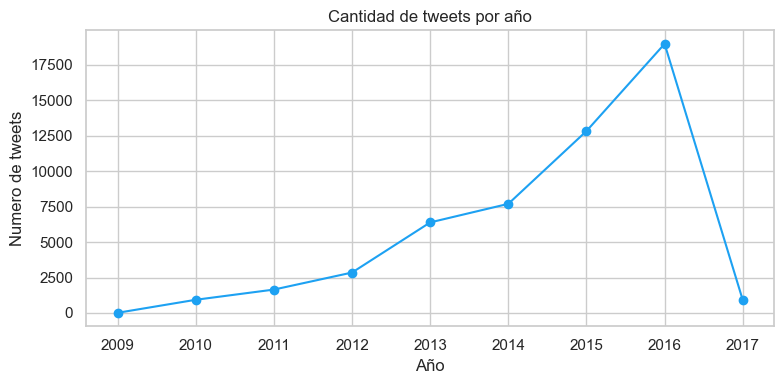

In [20]:
tweets_por_anio = df_clean.groupby("year").size()

fig, ax = plt.subplots(figsize=(8, 4))
tweets_por_anio.plot(kind="line", marker="o", ax=ax, color="#1DA1F2")
ax.set_title("Cantidad de tweets por año")
ax.set_xlabel("Año")
ax.set_ylabel("Numero de tweets")
plt.tight_layout()
plt.show()

## Wordcloud + conclusiones

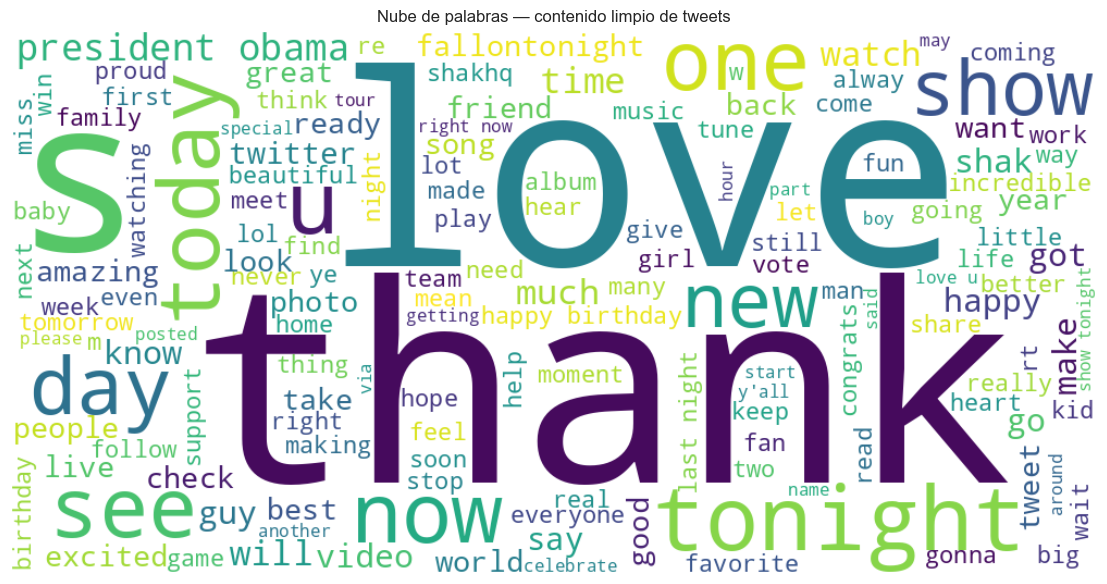

In [22]:
from wordcloud import WordCloud

texto_completo = " ".join(df_clean["content_clean"])

wc = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=150,
    colormap="viridis",
).generate(texto_completo)

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Nube de palabras — contenido limpio de tweets")
plt.tight_layout()
plt.show()


# Preguntas de análisis 1

### 1. ¿Qué cuentas son mencionadas con mayor frecuencia a lo largo del periodo?

Se normalizan las menciones a minúsculas para evitar que una misma cuenta se contabilice varias veces por diferencias de capitalización.

,numero_de_menciones
mentions,
jtimberlake,541
katyperry,318
jimmyfallon,254
cristiano,200
rihanna,175
nbcthevoice,148
vevo,139
itunesmusic,133
ofa,117


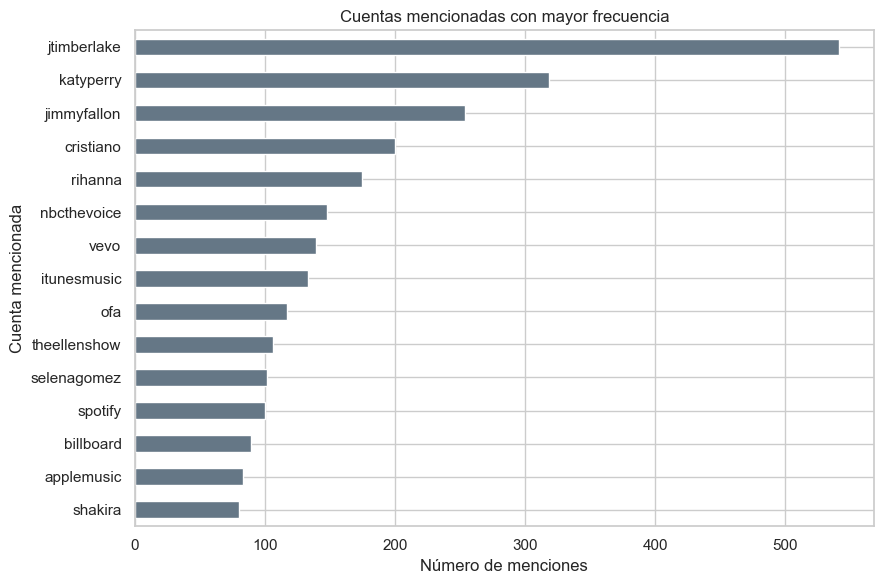

In [29]:
menciones_g06 = (
    df_clean["mentions"]
    .explode()
    .dropna()
    .astype(str)
    .str.lower()
    .str.lstrip("@")
)

top_menciones_g06 = menciones_g06.value_counts().head(15)
display(top_menciones_g06.rename("numero_de_menciones").to_frame())

fig, ax = plt.subplots(figsize=(9, 6))
top_menciones_g06.sort_values().plot(kind="barh", ax=ax, color="#657786")
ax.set_title("Cuentas mencionadas con mayor frecuencia")
ax.set_xlabel("Número de menciones")
ax.set_ylabel("Cuenta mencionada")
plt.tight_layout()
plt.show()

lideres = ", ".join(
    f"@{cuenta} ({cantidad:,})" for cuenta, cantidad in top_menciones_g06.head(5).items()
)
porcentaje_top5 = 100 * top_menciones_g06.head(5).sum() / len(menciones_g06)

La cuenta mencionada con mayor frecuencia es @jtimberlake, con 541 apariciones, seguida de @katyperry (318), @jimmyfallon (254), @cristiano (200) y @rihanna (175). 

Las cinco primeras solo reúnen el 5.5% de las 27,019 menciones, la conversación no está concentrada en unos pocos usuarios, sino repartida entre muchas cuentas. También aparecen perfiles relacionados con la música, los medios y las plataformas digitales, lo que refleja el peso del entretenimiento en el dataset.

### 2. ¿Qué horarios concentran más actividad según `tiempo_de_publicado`?

`tiempo_de_publicado` corresponde a `date_time`. Se extrae su hora y se contabilizan los tweets publicados en cada una de las 24 horas del día. Las horas conservan la zona horaria del dataset original.

,tweets,porcentaje
hora,,
0,2721,5.21
1,2531,4.84
2,2221,4.25
3,1995,3.82
4,1715,3.28
5,1352,2.59
6,1021,1.95
7,850,1.63
8,670,1.28


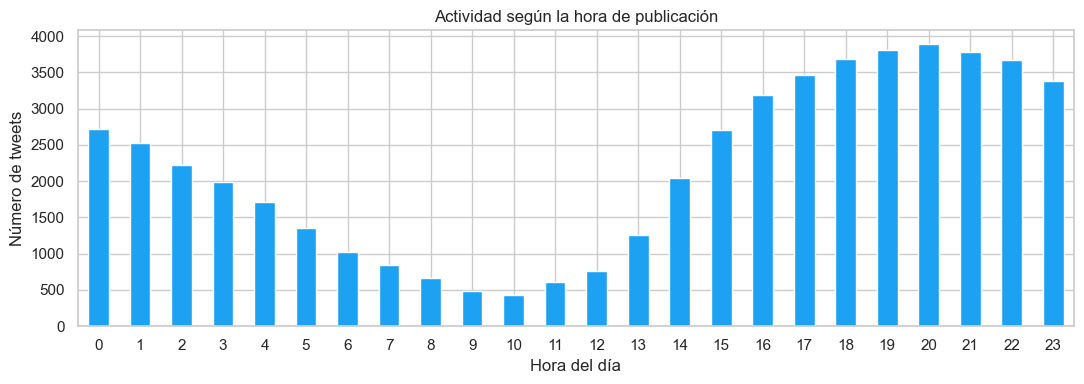

In [30]:
actividad_hora_g06 = (
    df_clean.assign(hora=df_clean["date_time"].dt.hour)
    .groupby("hora")
    .size()
    .reindex(range(24), fill_value=0)
    .rename("tweets")
    .to_frame()
)
actividad_hora_g06["porcentaje"] = (
    100 * actividad_hora_g06["tweets"] / actividad_hora_g06["tweets"].sum()
)
display(actividad_hora_g06.round(2))

fig, ax = plt.subplots(figsize=(11, 4))
actividad_hora_g06["tweets"].plot(kind="bar", ax=ax, color="#1DA1F2")
ax.set_title("Actividad según la hora de publicación")
ax.set_xlabel("Hora del día")
ax.set_ylabel("Número de tweets")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

horas_pico = actividad_hora_g06.nlargest(5, "tweets")
texto_horas = ", ".join(
    f"{hora:02d}:00 ({int(fila.tweets):,} tweets)"
    for hora, fila in horas_pico.iterrows()
)
franja_pico = actividad_hora_g06.loc[horas_pico.index, "tweets"].sum()
franja_pct = 100 * franja_pico / actividad_hora_g06["tweets"].sum()

La mayor actividad se concentra entre las 18:00 y las 22:00, siendo las 20:00 la hora con más publicaciones (3,885 tweets), seguida de las 19:00, 21:00, 18:00 y 22:00. En cambio, la actividad disminuye durante la madrugada y alcanza su mínimo a las 10:00, para después crecer de forma sostenida durante la tarde. 

Por tanto, la tarde-noche es el periodo de publicación más frecuente, aunque las horas deben interpretarse según la zona horaria con la que se registró el dataset.

### 3. ¿Qué hashtags dominan la conversación y cómo cambian en el tiempo?

Se muestran los hashtags más frecuentes del periodo completo y su evolución anual. La comparación anual usa los principales hashtags globales para conservar la misma escala entre años.

,frecuencia_total
hashtag,
fallontonight,1079
actonclimate,277
tbt,234
dailyfluff,215
lovetwitter,166
ts1989,165
1,162
fallonmono,152
confident,149


hashtag,fallontonight,actonclimate,tbt,dailyfluff,lovetwitter,ts1989,1,fallonmono,confident,doyourjob
anio,,,,,,,,,,
2010,0,0,0,0,0,0,1,0,0,0
2011,0,0,0,0,0,0,4,0,0,0
2012,0,0,1,0,0,0,14,0,0,0
2013,1,0,12,0,0,0,28,27,0,0
2014,330,50,29,0,0,165,46,104,0,0
2015,373,132,93,0,0,0,33,21,144,0
2016,363,95,97,215,166,0,35,0,5,147
2017,12,0,2,0,0,0,1,0,0,0


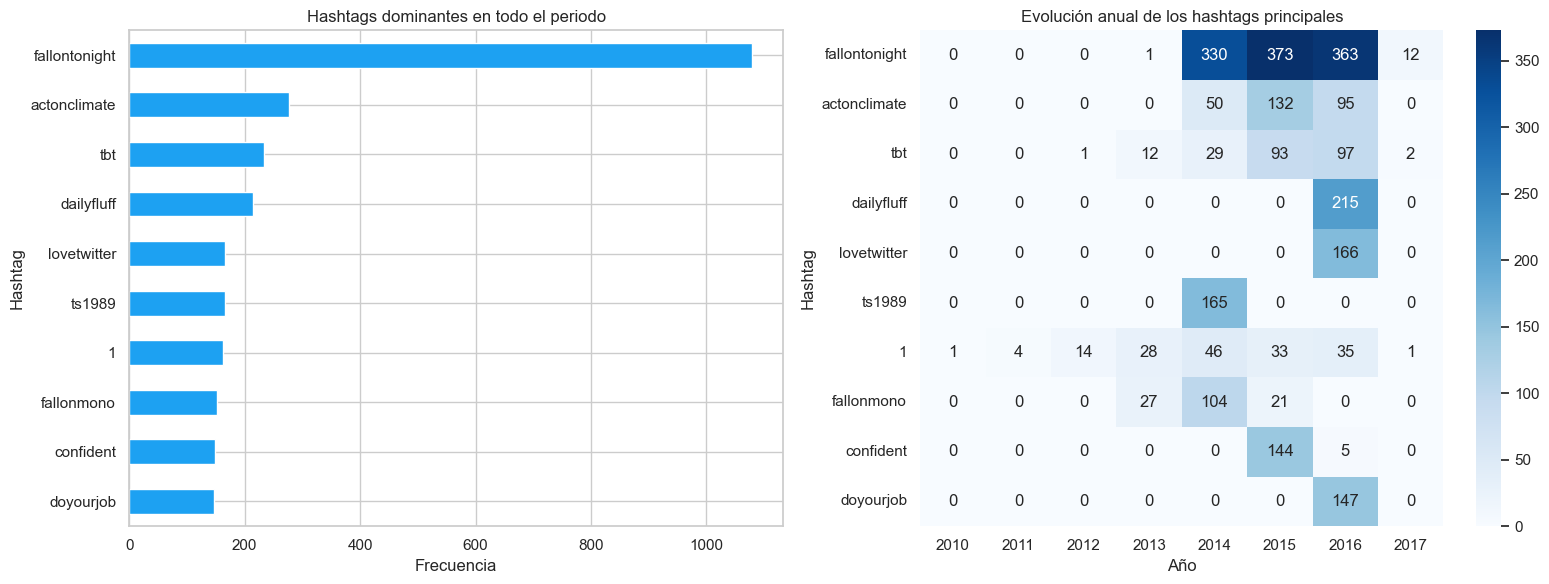

,anio,hashtag,frecuencia
0,2009,appwednesday,2
1,2010,worldcup,23
2,2011,intime,49
3,2012,unapologetic,74
4,2013,the2020experience,87
5,2014,fallontonight,330
6,2015,fallontonight,373
7,2016,fallontonight,363
8,2017,goldenglobes,14


In [31]:
hashtags_tiempo_g06 = (
    df_clean[["date_time", "hashtags"]]
    .explode("hashtags")
    .dropna(subset=["hashtags"])
    .assign(
        hashtag=lambda d: d["hashtags"].astype(str).str.lower().str.lstrip("#"),
        anio=lambda d: d["date_time"].dt.year,
    )
)
hashtags_tiempo_g06 = hashtags_tiempo_g06[hashtags_tiempo_g06["hashtag"].ne("")]

top_hashtags_g06 = hashtags_tiempo_g06["hashtag"].value_counts().head(10)
display(top_hashtags_g06.rename("frecuencia_total").to_frame())

evolucion_hashtags_g06 = (
    hashtags_tiempo_g06[hashtags_tiempo_g06["hashtag"].isin(top_hashtags_g06.index)]
    .groupby(["anio", "hashtag"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=top_hashtags_g06.index, fill_value=0)
)
display(evolucion_hashtags_g06)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top_hashtags_g06.sort_values().plot(kind="barh", ax=axes[0], color="#1DA1F2")
axes[0].set_title("Hashtags dominantes en todo el periodo")
axes[0].set_xlabel("Frecuencia")
axes[0].set_ylabel("Hashtag")

sns.heatmap(evolucion_hashtags_g06.T, cmap="Blues", annot=True, fmt="g", ax=axes[1])
axes[1].set_title("Evolución anual de los hashtags principales")
axes[1].set_xlabel("Año")
axes[1].set_ylabel("Hashtag")
plt.tight_layout()
plt.show()

dominante_anual_g06 = (
    hashtags_tiempo_g06.groupby(["anio", "hashtag"]).size()
    .rename("frecuencia")
    .reset_index()
    .sort_values(["anio", "frecuencia"], ascending=[True, False])
    .groupby("anio", as_index=False)
    .first()
)
display(dominante_anual_g06)

lider_global = top_hashtags_g06.index[0]

El hashtag dominante es #fallontonight, con 1,079 apariciones, concentradas casi por completo entre 2014 y 2016. Sin embargo, el tema principal cambia según el año: destacan #worldcup en 2010, #intime en 2011, #unapologetic en 2012, #the2020experience en 2013 y #goldenglobes en 2017.

La conversación está condicionada por eventos, campañas y lanzamientos específicos, en lugar de mantener los mismos temas durante todo el periodo.

### 4. ¿Cuántos tweets tiene cada autor y qué tan balanceado está el dataset?

,n_tweets,porcentaje
author,,
TheEllenShow,3147,6.02
jimmyfallon,3120,5.97
ArianaGrande,3081,5.9
YouTube,3073,5.88
KimKardashian,2926,5.6
katyperry,2908,5.56
selenagomez,2868,5.49
BarackObama,2863,5.48
rihanna,2852,5.46


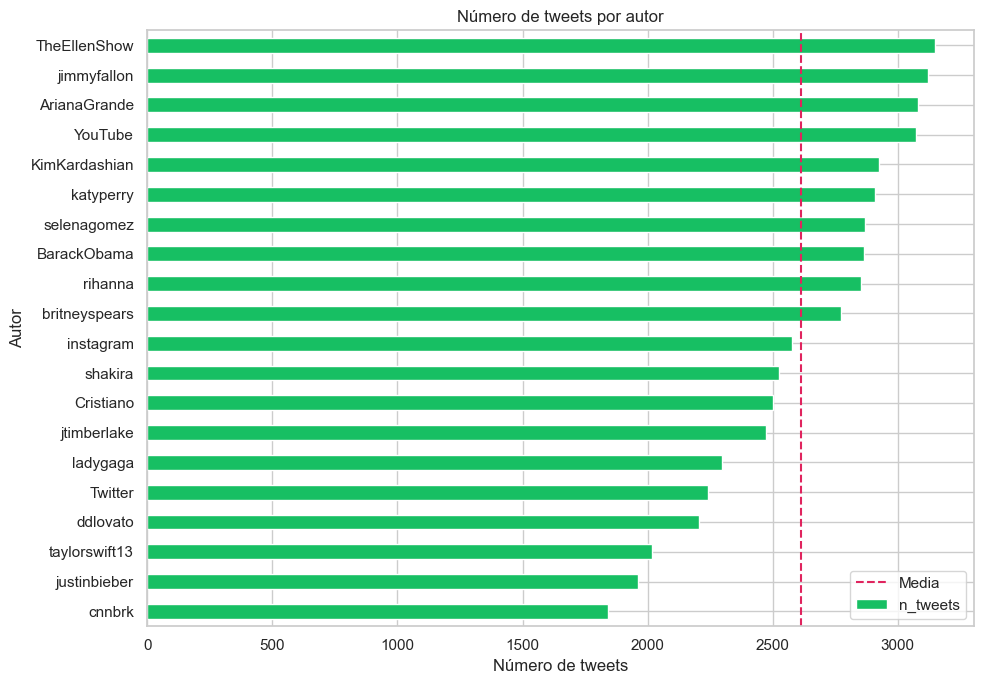

Media por autor: 2,612.8 tweets
Desviación estándar: 409.2 tweets
Coeficiente de variación: 0.157


In [35]:
tweets_autor_g06 = (
    df_clean["author"]
    .value_counts()
    .rename("n_tweets")
    .to_frame()
)

tweets_autor_g06["porcentaje"] = (
    100 * tweets_autor_g06["n_tweets"] / len(df_clean)
)

display(tweets_autor_g06.round(2))

conteos_g06 = tweets_autor_g06["n_tweets"].to_numpy()

media_g06 = conteos_g06.mean()
desviacion_g06 = conteos_g06.std(ddof=1)
cv_g06 = desviacion_g06 / media_g06
ratio_g06 = conteos_g06.max() / conteos_g06.min()

fig, ax = plt.subplots(figsize=(10, 7))

tweets_autor_g06["n_tweets"].sort_values().plot(
    kind="barh",
    ax=ax,
    color="#17BF63"
)

ax.axvline(
    media_g06,
    color="#E0245E",
    linestyle="--",
    label="Media"
)

ax.set_title("Número de tweets por autor")
ax.set_xlabel("Número de tweets")
ax.set_ylabel("Autor")
ax.legend()

plt.tight_layout()
plt.show()

diagnostico_g06 = (
    "bastante balanceado"
    if cv_g06 < 0.25 and ratio_g06 < 2
    else "desbalanceado"
)

print(f"Media por autor: {media_g06:,.1f} tweets")
print(f"Desviación estándar: {desviacion_g06:,.1f} tweets")
print(f"Coeficiente de variación: {cv_g06:.3f}")

El dataset está bastante balanceado en cuanto al número de tweets por autor. Cada cuenta tiene una media de 2,612.8 publicaciones y una desviación estándar de 409.2 tweets. El coeficiente de variación es 0.157, lo que significa que la dispersión representa aproximadamente el 15.7% de la media y, por tanto, las diferencias entre autores son relativamente pequeñas. 

TheEllenShow presenta el mayor número de tweets, con 3,147, mientras que cnnbrk tiene el menor, con 1,842. Aunque existen diferencias de volumen, ninguna cuenta domina claramente el dataset y la distribución de publicaciones entre autores es bastante uniforme.

### 5. ¿Cuál es el periodo de observación de cada autor?

Para cada cuenta se calculan la primera y la última fecha registradas y los días naturales transcurridos entre ambas, contando también el día inicial.

C:\Users\maria\AppData\Local\Temp\ipykernel_8732\526848934.py:18: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(periodo_autor_g06.round(2))


,fecha_inicial,fecha_final,n_tweets,dias_activos,dias_observados,cobertura_pct
author,,,,,,
Twitter,2009-12-18,2017-01-24,2243,1071,2595,41.27
jtimberlake,2010-03-29,2017-01-23,2473,1083,2493,43.44
Cristiano,2010-06-15,2017-01-16,2501,1283,2408,53.28
selenagomez,2010-05-31,2016-08-13,2868,1226,2267,54.08
taylorswift13,2011-04-24,2017-01-14,2019,950,2093,45.39
shakira,2011-12-24,2017-01-16,2525,1003,1851,54.19
katyperry,2012-08-28,2017-01-12,2908,987,1599,61.73
rihanna,2012-10-11,2017-01-16,2852,758,1559,48.62
britneyspears,2012-10-18,2017-01-13,2772,781,1549,50.42


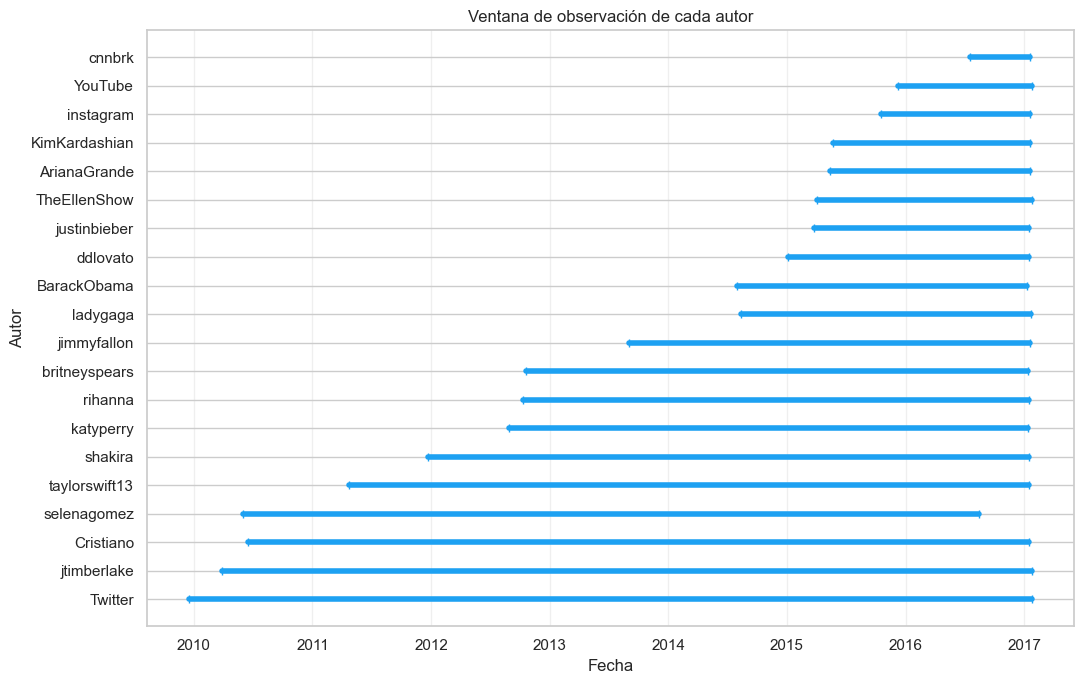

In [33]:
periodo_autor_g06 = (
    df_clean.assign(fecha=df_clean["date_time"].dt.normalize())
    .groupby("author")
    .agg(
        fecha_inicial=("fecha", "min"),
        fecha_final=("fecha", "max"),
        n_tweets=("fecha", "size"),
        dias_activos=("fecha", "nunique"),
    )
)
periodo_autor_g06["dias_observados"] = (
    periodo_autor_g06["fecha_final"] - periodo_autor_g06["fecha_inicial"]
).dt.days + 1
periodo_autor_g06["cobertura_pct"] = (
    100 * periodo_autor_g06["dias_activos"] / periodo_autor_g06["dias_observados"]
)
periodo_autor_g06 = periodo_autor_g06.sort_values("dias_observados", ascending=False)
display(periodo_autor_g06.round(2))

fig, ax = plt.subplots(figsize=(11, 7))
for y, (autor, fila) in enumerate(periodo_autor_g06.iterrows()):
    ax.plot([fila["fecha_inicial"], fila["fecha_final"]], [y, y],
            marker="|", linewidth=4, color="#1DA1F2")
ax.set_yticks(range(len(periodo_autor_g06)))
ax.set_yticklabels(periodo_autor_g06.index)
ax.set_title("Ventana de observación de cada autor")
ax.set_xlabel("Fecha")
ax.set_ylabel("Autor")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

mas_largo = periodo_autor_g06.iloc[0]
mas_corto = periodo_autor_g06.iloc[-1]

El periodo de observación cambia considerablemente entre autores. Twitter presenta la ventana más larga, con 2,595 días entre el 18 de diciembre de 2009 y el 24 de enero de 2017, mientras que cnnbrk solo fue observado durante 185 días, desde el 17 de julio de 2016 hasta el 17 de enero de 2017. 

La ventana más larga es aproximadamente 14 veces mayor que la más corta y la proporción de días activos también varía entre cuentas. Por ello, comparar únicamente el total de tweets puede ser engañoso y resulta más adecuado considerar también los tweets por día observado, los días activos y la cobertura de cada autor.

## Preguntas de análisis 2

### 6. ¿Qué autores publican con mayor frecuencia?

Se construyen tres medidas:

- dias_observados: días de calendario entre el primer y el último tweet del autor (inclusive).
- tweets_por_dia: frecuencia real de publicación sobre esa ventana.
- tweets_por_dia_activo: intensidad en los días en que sí publicó.
- cobertura: proporción de días de la ventana con al menos un tweet (regularidad).

In [23]:
from scipy import stats

# Dia calendario de cada tweet (base para la ventana de observacion por autor)
df_clean["dia"] = df_clean["date_time"].dt.normalize()

g = df_clean.groupby("author")
frecuencia = pd.DataFrame({
    "n_tweets": g.size(),
    "primer_tweet": g["dia"].min(),
    "ultimo_tweet": g["dia"].max(),
    "dias_activos": g["dia"].nunique(),
})
frecuencia["dias_observados"] = (
    frecuencia["ultimo_tweet"] - frecuencia["primer_tweet"]
).dt.days + 1

frecuencia["tweets_por_dia"] = frecuencia["n_tweets"] / frecuencia["dias_observados"]
frecuencia["tweets_por_dia_activo"] = frecuencia["n_tweets"] / frecuencia["dias_activos"]
frecuencia["cobertura"] = frecuencia["dias_activos"] / frecuencia["dias_observados"]

frecuencia["rank_volumen"] = frecuencia["n_tweets"].rank(ascending=False).astype(int)
frecuencia["rank_frecuencia"] = frecuencia["tweets_por_dia"].rank(ascending=False).astype(int)
frecuencia["salto"] = frecuencia["rank_volumen"] - frecuencia["rank_frecuencia"]

frecuencia = frecuencia.sort_values("tweets_por_dia", ascending=False)
frecuencia[[
    "n_tweets", "dias_observados", "dias_activos", "tweets_por_dia",
    "tweets_por_dia_activo", "cobertura", "rank_volumen", "rank_frecuencia", "salto",
]].round(2)

,n_tweets,dias_observados,dias_activos,tweets_por_dia,tweets_por_dia_activo,cobertura,rank_volumen,rank_frecuencia,salto
author,,,,,,,,,
cnnbrk,1842,185,185,9.96,9.96,1.00,20,1,19
YouTube,3073,413,407,7.44,7.55,0.99,4,2,2
instagram,2577,458,458,5.63,5.63,1.00,11,3,8
ArianaGrande,3081,615,493,5.01,6.25,0.80,3,4,-1
KimKardashian,2926,605,491,4.84,5.96,0.81,5,5,0
TheEllenShow,3147,663,610,4.75,5.16,0.92,1,6,-5
BarackObama,2863,895,696,3.20,4.11,0.78,8,7,1
ddlovato,2207,742,559,2.97,3.95,0.75,17,8,9
justinbieber,1962,665,443,2.95,4.43,0.67,19,9,10


In [24]:
# El volumen total NO ordena igual que la frecuencia real
rho, p = stats.spearmanr(frecuencia["n_tweets"], frecuencia["tweets_por_dia"])
print(f"Spearman(total de tweets, tweets por dia) = {rho:.3f}  (p = {p:.3f})")

print("\nAutores que mas cambian de posicion al normalizar por ventana observada:")
mayores_saltos = frecuencia.reindex(
    frecuencia["salto"].abs().sort_values(ascending=False).index
)
print(mayores_saltos[[
    "n_tweets", "dias_observados", "tweets_por_dia", "rank_volumen", "rank_frecuencia", "salto",
]].head(6).round(2))

Spearman(total de tweets, tweets por dia) = 0.281  (p = 0.230)

Autores que mas cambian de posicion al normalizar por ventana observada:
              n_tweets  dias_observados  tweets_por_dia  rank_volumen  \
author                                                                  
cnnbrk            1842              185            9.96            20   
justinbieber      1962              665            2.95            19   
ddlovato          2207              742            2.97            17   
jimmyfallon       3120             1233            2.53             2   
selenagomez       2868             2267            1.27             7   
instagram         2577              458            5.63            11   

              rank_frecuencia  salto  
author                                
cnnbrk                      1     19  
justinbieber                9     10  
ddlovato                    8      9  
jimmyfallon                11     -9  
selenagomez                16     -9  
insta

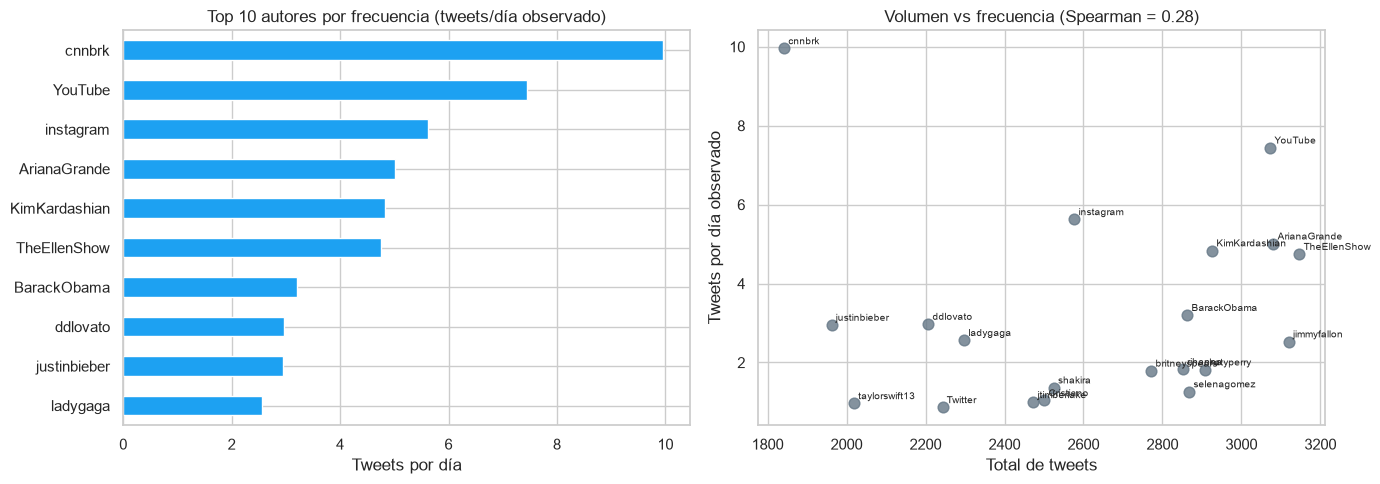

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_frec = frecuencia["tweets_por_dia"].head(10)
top_frec.iloc[::-1].plot(kind="barh", ax=axes[0], color="#1DA1F2")
axes[0].set_title("Top 10 autores por frecuencia (tweets/día observado)")
axes[0].set_xlabel("Tweets por día")
axes[0].set_ylabel("")

axes[1].scatter(frecuencia["n_tweets"], frecuencia["tweets_por_dia"],
                s=60, color="#657786", alpha=0.8)
for autor, fila in frecuencia.iterrows():
    axes[1].annotate(autor, (fila["n_tweets"], fila["tweets_por_dia"]),
                     fontsize=7, xytext=(3, 3), textcoords="offset points")
axes[1].set_title(f"Volumen vs frecuencia (Spearman = {rho:.2f})")
axes[1].set_xlabel("Total de tweets")
axes[1].set_ylabel("Tweets por día observado")

plt.tight_layout()
plt.show()

Los autores con mayor frecuencia de publicación son cnnbrk (9.96 tweets diarios), YouTube (7.44), instagram (5.63), ArianaGrande (5.01) y KimKardashian (4.84).

No es adecuado comparar únicamente el total de tweets, ya que cada cuenta fue observada durante periodos diferentes. Por ejemplo, cnnbrk tiene la menor cantidad de tweets, pero ocupa el primer lugar en frecuencia porque publicó diariamente durante los 185 días registrados. En cambio, cuentas como TheEllenShow y jimmyfallon tienen muchos tweets, pero distribuidos en periodos más largos.

La cobertura también muestra dos comportamientos: las cuentas institucionales, como cnnbrk, instagram y YouTube, publican de manera constante; mientras que las personales, como Twitter, jtimberlake y taylorswift13, suelen publicar varios tweets en ciertos días y luego permanecer inactivas.

### 7. ¿Qué autores reciben más likes y shares por tweet?

Se reporta la media por tweet con su intervalo de
confianza al 95% y la mediana, que es más informativa porque la distribución de likes está muy
sesgada a la derecha (unos pocos tweets virales inflan la media).

In [26]:
engagement = df_clean.groupby("author").agg(
    n_tweets=("number_of_likes", "size"),
    likes_total=("number_of_likes", "sum"),
    likes_medio=("number_of_likes", "mean"),
    likes_mediana=("number_of_likes", "median"),
    shares_total=("number_of_shares", "sum"),
    shares_medio=("number_of_shares", "mean"),
    shares_mediana=("number_of_shares", "median"),
)

# Intervalo de confianza 95% de la media de likes
error_std = df_clean.groupby("author")["number_of_likes"].sem()
engagement["ic95_bajo"] = engagement["likes_medio"] - 1.96 * error_std
engagement["ic95_alto"] = engagement["likes_medio"] + 1.96 * error_std

engagement["rank_suma"] = engagement["likes_total"].rank(ascending=False).astype(int)
engagement["rank_por_tweet"] = engagement["likes_medio"].rank(ascending=False).astype(int)
engagement["salto"] = engagement["rank_suma"] - engagement["rank_por_tweet"]

engagement = engagement.sort_values("likes_medio", ascending=False)
engagement[[
    "n_tweets", "likes_total", "likes_medio", "likes_mediana", "ic95_bajo", "ic95_alto",
    "rank_suma", "rank_por_tweet", "salto",
]].round(1)

,n_tweets,likes_total,likes_medio,likes_mediana,ic95_bajo,ic95_alto,rank_suma,rank_por_tweet,salto
author,,,,,,,,,
justinbieber,1962,127508117,64988.8,56979.5,63396.8,66580.9,1,1,0
ArianaGrande,3081,78572843,25502.4,21359.0,24972.0,26032.7,2,2,0
taylorswift13,2019,45119229,22347.3,12863.0,21155.1,23539.5,3,3,0
ddlovato,2207,38463172,17427.8,15168.0,16956.0,17899.6,4,4,0
KimKardashian,2926,32182230,10998.7,5556.0,10238.7,11758.7,5,5,0
selenagomez,2868,28173445,9823.4,5114.0,9176.1,10470.6,6,6,0
ladygaga,2298,19623352,8539.3,5314.0,8127.3,8951.3,9,7,2
katyperry,2908,24650617,8476.8,6570.5,8176.4,8777.2,7,8,-1
TheEllenShow,3147,22042176,7004.2,4216.0,6654.1,7354.3,8,9,-1


In [27]:
print("Autores ordenados por SHARES por tweet:")
print(engagement.sort_values("shares_medio", ascending=False)[
    ["n_tweets", "shares_total", "shares_medio", "shares_mediana"]
].round(1))

rho_suma, p_suma = stats.spearmanr(engagement["likes_total"], engagement["likes_medio"])
rho_ls, p_ls = stats.spearmanr(engagement["likes_medio"], engagement["shares_medio"])
print(f"\nSpearman(likes totales, likes por tweet)  = {rho_suma:.3f}  (p = {p_suma:.2g})")
print(f"Spearman(likes por tweet, shares por tweet) = {rho_ls:.3f}  (p = {p_ls:.2g})")

print(f"\nSesgo de la distribucion: media global = {df_clean['number_of_likes'].mean():.0f} "
      f"vs mediana global = {df_clean['number_of_likes'].median():.0f} likes")

Autores ordenados por SHARES por tweet:
               n_tweets  shares_total  shares_medio  shares_mediana
author                                                             
justinbieber       1962      88803359       45261.7         41451.0
taylorswift13      2019      25170484       12466.8          9067.0
ArianaGrande       3081      35283785       11452.1          9159.0
ddlovato           2207      22207863       10062.5          8678.0
selenagomez        2868      23264254        8111.7          6242.5
katyperry          2908      14357445        4937.2          3757.5
rihanna            2852      13471434        4723.5          2046.0
ladygaga           2298      10072137        4383.0          2909.5
Cristiano          2501       9319162        3726.2          1540.0
KimKardashian      2926       9166469        3132.8           965.0
TheEllenShow       3147       5760883        1830.6           743.0
BarackObama        2863       4960951        1732.8           795.0
britneys

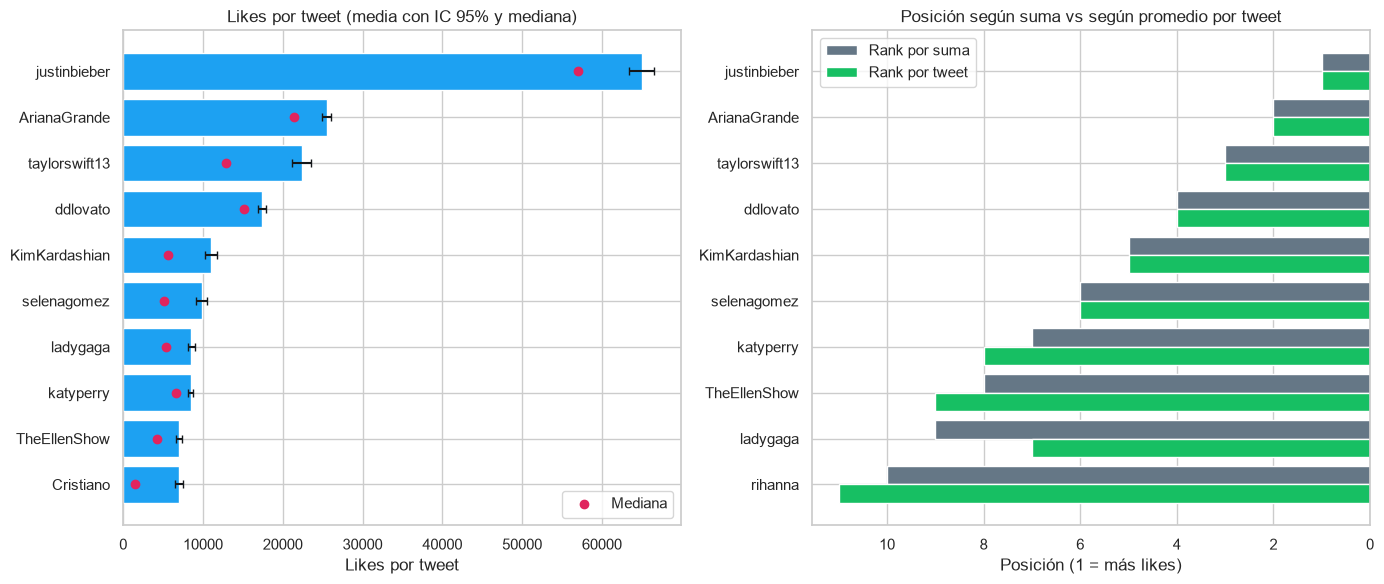

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_eng = engagement.head(10).iloc[::-1]
posiciones = range(len(top_eng))
axes[0].barh(posiciones, top_eng["likes_medio"], color="#1DA1F2",
             xerr=[top_eng["likes_medio"] - top_eng["ic95_bajo"],
                   top_eng["ic95_alto"] - top_eng["likes_medio"]],
             error_kw={"ecolor": "#14171A", "capsize": 3})
axes[0].scatter(top_eng["likes_mediana"], posiciones, color="#E0245E",
                zorder=3, label="Mediana")
axes[0].set_yticks(list(posiciones))
axes[0].set_yticklabels(top_eng.index)
axes[0].set_title("Likes por tweet (media con IC 95% y mediana)")
axes[0].set_xlabel("Likes por tweet")
axes[0].legend()

ancho = 0.4
orden = engagement.sort_values("likes_total", ascending=False).head(10).iloc[::-1]
pos = np.arange(len(orden))
axes[1].barh(pos + ancho / 2, orden["rank_suma"], height=ancho,
             color="#657786", label="Rank por suma")
axes[1].barh(pos - ancho / 2, orden["rank_por_tweet"], height=ancho,
             color="#17BF63", label="Rank por tweet")
axes[1].set_yticks(pos)
axes[1].set_yticklabels(orden.index)
axes[1].invert_xaxis()
axes[1].set_title("Posición según suma vs según promedio por tweet")
axes[1].set_xlabel("Posición (1 = más likes)")
axes[1].legend()

plt.tight_layout()
plt.show()

Por promedio de likes por tweet, los autores principales son justinbieber (64,989), ArianaGrande (25,502), taylorswift13 (22,347), ddlovato (17,428) y KimKardashian (10,999). En shares destacan justinbieber (45,262), taylorswift13 (12,467), ArianaGrande (11,452), ddlovato (10,063) y selenagomez (8,112).

Aunque es mejor utilizar promedios que totales, en este dataset ambos métodos producen resultados similares porque los autores tienen cantidades parecidas de tweets. Sin embargo, la media puede verse afectada por unos pocos tweets virales. Por eso, la mediana permite identificar qué cuentas mantienen una interacción más constante, como katyperry y jimmyfallon.

Los rankings de likes y shares también son similares, pero presentan algunas diferencias. Por ejemplo, el contenido de KimKardashian recibe proporcionalmente más likes que shares, mientras que con rihanna sucede lo contrario.

### 8. ¿Qué relación existe entre likes y shares?

Se mide de tres formas complementarias, porque ambas variables son de cola larga:
Pearson sobre los valores crudos (sensible a los tweets virales), Spearman sobre rangos
(robusto) y una regresión en escala log-log, cuya pendiente es la elasticidad: en cuánto
crecen los shares cuando los likes crecen 1%. Además se repite la correlación dentro de cada
autor, para verificar que la asociación no venga solo de que unas cuentas son más grandes
que otras.

In [31]:
likes = df_clean["number_of_likes"]
shares = df_clean["number_of_shares"]
log_likes, log_shares = np.log1p(likes), np.log1p(shares)

r_crudo, p_crudo = stats.pearsonr(likes, shares)
r_log, _ = stats.pearsonr(log_likes, log_shares)
rho_sp = stats.spearmanr(likes, shares)
pendiente, intercepto, r_val, _, _ = stats.linregress(log_likes, log_shares)

print(f"Pearson  (crudo)   r = {r_crudo:.4f}   p = {p_crudo:.2g}")
print(f"Pearson  (log1p)   r = {r_log:.4f}")
print(f"Spearman (rangos)  r = {rho_sp.statistic:.4f}   p = {rho_sp.pvalue:.2g}")
print(f"\nlog1p(shares) = {intercepto:.3f} + {pendiente:.3f} * log1p(likes)")
print(f"   R2 = {r_val ** 2:.3f}   elasticidad = {pendiente:.3f}")

ratio = (shares / likes.replace(0, np.nan))
print(f"\nRatio shares/likes por tweet -> mediana {ratio.median():.2f}, "
      f"P10 {ratio.quantile(0.10):.2f}, P90 {ratio.quantile(0.90):.2f}")

Pearson  (crudo)   r = 0.9205   p = 0
Pearson  (log1p)   r = 0.8871
Spearman (rangos)  r = 0.8748   p = 0

log1p(shares) = -0.001 + 0.910 * log1p(likes)
   R2 = 0.787   elasticidad = 0.910

Ratio shares/likes por tweet -> mediana 0.48, P10 0.17, P90 1.56


In [33]:
# La relacion se mantiene DENTRO de cada autor
correlacion_autor = df_clean.groupby("author").apply(
    lambda d: pd.Series({
        "n": len(d),
        "spearman": stats.spearmanr(d["number_of_likes"], d["number_of_shares"]).statistic,
        "pearson_log": stats.pearsonr(np.log1p(d["number_of_likes"]),
                                      np.log1p(d["number_of_shares"]))[0],
    }),
    include_groups=False,
).sort_values("spearman", ascending=False)

print(correlacion_autor.round(3))
print(f"\nSpearman intra-autor: minimo {correlacion_autor['spearman'].min():.3f}, "
      f"mediana {correlacion_autor['spearman'].median():.3f}, "
      f"maximo {correlacion_autor['spearman'].max():.3f}")

decil = pd.qcut(likes.rank(method="first"), 10, labels=False) + 1
por_decil = df_clean.groupby(decil).agg(
    likes_mediana=("number_of_likes", "median"),
    shares_mediana=("number_of_shares", "median"),
)
print("\nMediana de shares por decil de likes:")
print(por_decil.round(0))

                    n  spearman  pearson_log
author                                      
YouTube        3073.0     0.962        0.959
KimKardashian  2926.0     0.957        0.962
instagram      2577.0     0.953        0.952
selenagomez    2868.0     0.945        0.951
ArianaGrande   3081.0     0.929        0.910
Cristiano      2501.0     0.928        0.925
ladygaga       2298.0     0.925        0.928
TheEllenShow   3147.0     0.922        0.924
britneyspears  2772.0     0.913        0.917
rihanna        2852.0     0.911        0.908
ddlovato       2207.0     0.902        0.934
taylorswift13  2019.0     0.873        0.862
BarackObama    2863.0     0.873        0.895
justinbieber   1962.0     0.868        0.903
jtimberlake    2473.0     0.850        0.888
jimmyfallon    3120.0     0.842        0.869
katyperry      2908.0     0.817        0.812
cnnbrk         1842.0     0.773        0.790
Twitter        2243.0     0.757        0.792
shakira        2525.0     0.701        0.708

Spearman 

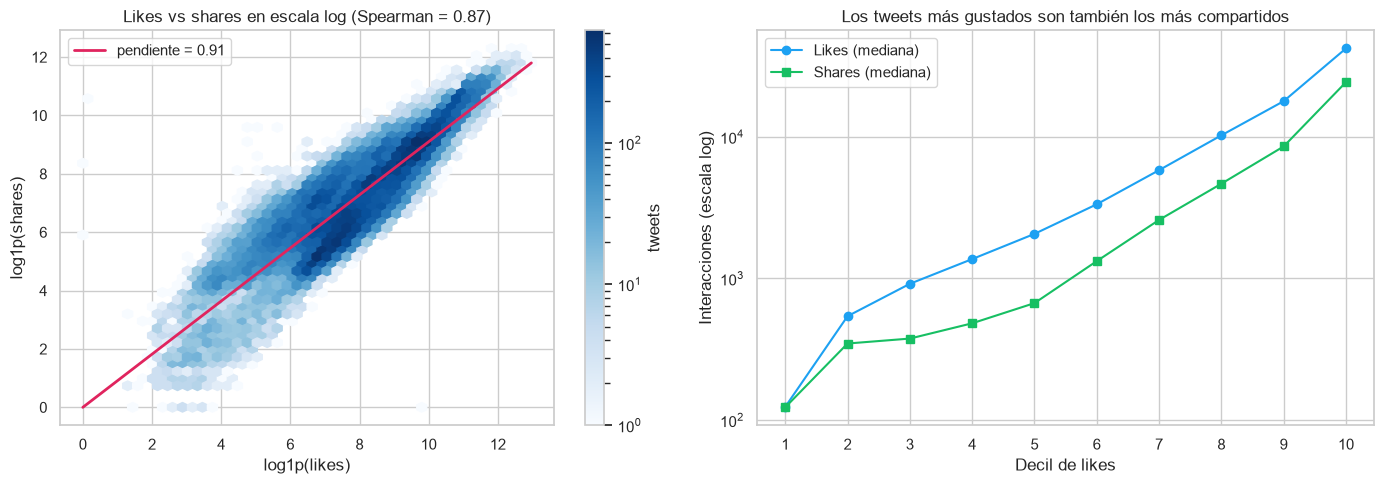

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hb = axes[0].hexbin(log_likes, log_shares, gridsize=45, cmap="Blues", mincnt=1, bins="log")
x_linea = np.linspace(log_likes.min(), log_likes.max(), 100)
axes[0].plot(x_linea, intercepto + pendiente * x_linea, color="#E0245E", lw=2,
             label=f"pendiente = {pendiente:.2f}")
axes[0].set_title(f"Likes vs shares en escala log (Spearman = {rho_sp.statistic:.2f})")
axes[0].set_xlabel("log1p(likes)")
axes[0].set_ylabel("log1p(shares)")
axes[0].legend()
fig.colorbar(hb, ax=axes[0], label="tweets")

axes[1].plot(por_decil.index, por_decil["likes_mediana"], marker="o",
             color="#1DA1F2", label="Likes (mediana)")
axes[1].plot(por_decil.index, por_decil["shares_mediana"], marker="s",
             color="#17BF63", label="Shares (mediana)")
axes[1].set_yscale("log")
axes[1].set_title("Los tweets más gustados son también los más compartidos")
axes[1].set_xlabel("Decil de likes")
axes[1].set_ylabel("Interacciones (escala log)")
axes[1].set_xticks(list(por_decil.index))
axes[1].legend()

plt.tight_layout()
plt.show()

Sí, los tweets con más likes también suelen ser los más compartidos. La relación es fuerte y positiva, como muestran las correlaciones de Pearson (0.921) y Spearman (0.875). Además, no se debe únicamente a unos pocos tweets virales.

La relación se mantiene incluso al analizar cada autor por separado: los 20 autores presentan una correlación superior a 0.70. Esto confirma que, dentro de una misma cuenta, los tweets con más likes generalmente reciben más shares.

Sin embargo, likes y shares no representan exactamente lo mismo. Un tweet típico recibe aproximadamente la mitad de shares que de likes, aunque esta proporción puede variar bastante. Esto permite distinguir entre el contenido que simplemente gusta y aquel que las personas deciden compartir.

### 9. ¿Los tweets con hashtags, menciones, enlaces o cierta longitud reciben más engagement?

Primero la comparación ingenua (todos los tweets juntos) y después la misma comparación
dentro de cada autor. 

El control se hace de tres maneras: tasa de aciertos por autor (en cuántas de las 20 cuentas
la característica sube la mediana), likes normalizados por la mediana de cada autor, y una
regresión sobre `log1p(likes)` con efectos fijos de autor y de autor x año, con errores
estándar agrupados por autor.

In [35]:
# Caracteristicas del texto
df_clean["n_mentions"] = df_clean["mentions"].str.len()
df_clean["tiene_hashtag"] = df_clean["n_hashtags"] > 0
df_clean["tiene_mencion"] = df_clean["n_mentions"] > 0
df_clean["tiene_enlace"] = df_clean["has_url"].astype(bool)
df_clean["cuartil_longitud"] = pd.qcut(
    df_clean["text_length"], 4, labels=["Q1 corto", "Q2", "Q3", "Q4 largo"]
)

def comparacion_global(col):
    tabla = df_clean.groupby(col).agg(
        n=("number_of_likes", "size"),
        likes_medio=("number_of_likes", "mean"),
        likes_mediana=("number_of_likes", "median"),
        shares_medio=("number_of_shares", "mean"),
        shares_mediana=("number_of_shares", "median"),
    ).round(1)
    con = df_clean.loc[df_clean[col], "number_of_likes"]
    sin = df_clean.loc[~df_clean[col], "number_of_likes"]
    u = stats.mannwhitneyu(con, sin, alternative="two-sided")
    delta = 2 * u.statistic / (len(con) * len(sin)) - 1   # Cliff's delta
    print(f"\n[{col}]  Mann-Whitney p = {u.pvalue:.2g}   Cliff's delta = {delta:.3f}")
    print(tabla)

for columna in ["tiene_hashtag", "tiene_mencion", "tiene_enlace"]:
    comparacion_global(columna)

print("\n[cuartil de longitud del texto limpio]")
print(df_clean.groupby("cuartil_longitud", observed=True).agg(
    n=("number_of_likes", "size"),
    longitud_media=("text_length", "mean"),
    likes_medio=("number_of_likes", "mean"),
    likes_mediana=("number_of_likes", "median"),
    shares_mediana=("number_of_shares", "median"),
).round(1))
kw = stats.kruskal(*[grupo["number_of_likes"].values
                     for _, grupo in df_clean.groupby("cuartil_longitud", observed=True)])
print(f"Kruskal-Wallis longitud vs likes: H = {kw.statistic:.1f}, p = {kw.pvalue:.2g}")


[tiene_hashtag]  Mann-Whitney p = 4e-16   Cliff's delta = -0.042
                   n  likes_medio  likes_mediana  shares_medio  shares_mediana
tiene_hashtag                                                                 
False          31696       9844.2         2959.5        5294.6          1372.0
True           20561       9102.8         2179.0        5408.0          1121.0

[tiene_mencion]  Mann-Whitney p = 0   Cliff's delta = -0.227
                   n  likes_medio  likes_mediana  shares_medio  shares_mediana
tiene_mencion                                                                 
False          32207      11015.0         3448.0        6135.7          1754.0
True           20050       7203.1         1743.0        4059.7           752.0

[tiene_enlace]  Mann-Whitney p = 1e-43   Cliff's delta = 0.074
                  n  likes_medio  likes_mediana  shares_medio  shares_mediana
tiene_enlace                                                                 
False         17637 

In [36]:
# Misma comparacion, pero DENTRO de cada autor
print("Tasa de aciertos por autor (mediana de likes mayor CON la caracteristica):\n")
for columna in ["tiene_hashtag", "tiene_mencion", "tiene_enlace"]:
    medianas = df_clean.groupby(["author", columna])["number_of_likes"].median().unstack().dropna()
    aciertos = int((medianas[True] > medianas[False]).sum())
    ratio = (medianas[True] / medianas[False]).median()
    print(f"  {columna:15s} {aciertos:2d}/{len(medianas)} autores   "
          f"ratio mediano con/sin = {ratio:.2f}")

# Longitud: cuartiles definidos dentro de cada autor y likes relativos a su mediana
df_clean["cuartil_longitud_autor"] = df_clean.groupby("author")["text_length"].transform(
    lambda s: pd.qcut(s, 4, labels=["Q1 corto", "Q2", "Q3", "Q4 largo"], duplicates="drop")
)
df_clean["likes_rel"] = df_clean.groupby("author")["number_of_likes"].transform(
    lambda s: s / s.median()
)

print("\nLongitud con cuartiles calculados dentro de cada autor:")
print(df_clean.groupby("cuartil_longitud_autor", observed=True).agg(
    n=("number_of_likes", "size"),
    likes_mediana=("number_of_likes", "median"),
    likes_rel_mediana=("likes_rel", "median"),
).round(2))

tabla_long = df_clean.pivot_table(index="author", columns="cuartil_longitud_autor",
                                  values="number_of_likes", aggfunc="median", observed=True)
aciertos_long = int((tabla_long["Q1 corto"] > tabla_long["Q4 largo"]).sum())
print(f"\nAutores donde los tweets cortos superan a los largos: "
      f"{aciertos_long}/{len(tabla_long)} (azar = 10/20)")

Tasa de aciertos por autor (mediana de likes mayor CON la caracteristica):

  tiene_hashtag   16/20 autores   ratio mediano con/sin = 1.13
  tiene_mencion    3/20 autores   ratio mediano con/sin = 0.66
  tiene_enlace    14/20 autores   ratio mediano con/sin = 1.50

Longitud con cuartiles calculados dentro de cada autor:
                            n  likes_mediana  likes_rel_mediana
cuartil_longitud_autor                                         
Q1 corto                13490         2760.0               0.98
Q2                      12920         2420.5               0.96
Q3                      13042         2585.5               1.02
Q4 largo                12805         2590.0               1.04

Autores donde los tweets cortos superan a los largos: 10/20 (azar = 10/20)


In [37]:
def ols_efectos_fijos(y, X, grupos, clusters, nombres):
    """OLS con efectos fijos (transformacion within) y errores estandar agrupados."""
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)
    idx = pd.factorize(grupos)[0]
    conteo = np.bincount(idx)

    def centrar(M):
        M = np.atleast_2d(M.T).T
        salida = np.empty_like(M)
        for j in range(M.shape[1]):
            medias = np.bincount(idx, weights=M[:, j]) / conteo
            salida[:, j] = M[:, j] - medias[idx]
        return salida

    y_c, X_c = centrar(y.reshape(-1, 1)).ravel(), centrar(X)
    beta = np.linalg.lstsq(X_c, y_c, rcond=None)[0]
    residuos = y_c - X_c @ beta

    XtX_inv = np.linalg.inv(X_c.T @ X_c)
    idx_cluster = pd.factorize(clusters)[0]
    meat = np.zeros((X_c.shape[1], X_c.shape[1]))
    for c in np.unique(idx_cluster):
        m = idx_cluster == c
        u = X_c[m].T @ residuos[m]
        meat += np.outer(u, u)
    errores = np.sqrt(np.diag(XtX_inv @ meat @ XtX_inv))

    r2 = 1 - (residuos ** 2).sum() / ((y_c - y_c.mean()) ** 2).sum()
    tabla = pd.DataFrame({
        "coef": beta,
        "se_cluster": errores,
        "t": beta / errores,
        "efecto_%": (np.exp(beta) - 1) * 100,
    }, index=nombres).round(3)
    return tabla, r2


df_clean["log_longitud"] = np.log(df_clean["text_length"].clip(lower=1))
predictores = ["tiene_hashtag", "tiene_mencion", "tiene_enlace", "log_longitud"]
X = df_clean[predictores].astype(float).values
autor_anio = df_clean["author"].astype(str) + "_" + df_clean["year"].astype(str)

for objetivo in ["number_of_likes", "number_of_shares"]:
    y = np.log1p(df_clean[objetivo])
    tabla, r2 = ols_efectos_fijos(y, X, df_clean["author"], df_clean["author"], predictores)
    print(f"\nlog1p({objetivo}) | efectos fijos de AUTOR        R2 within = {r2:.3f}  n = {len(df_clean)}")
    print(tabla)
    tabla2, r2b = ols_efectos_fijos(y, X, autor_anio, df_clean["author"], predictores)
    print(f"log1p({objetivo}) | efectos fijos de AUTOR x AÑO   R2 within = {r2b:.3f}")
    print(tabla2)


log1p(number_of_likes) | efectos fijos de AUTOR        R2 within = 0.113  n = 52257
                coef  se_cluster      t  efecto_%
tiene_hashtag  0.154       0.083  1.856    16.688
tiene_mencion -0.545       0.088 -6.168   -41.993
tiene_enlace   0.571       0.194  2.950    77.022
log_longitud   0.052       0.061  0.857     5.347
log1p(number_of_likes) | efectos fijos de AUTOR x AÑO   R2 within = 0.148
                coef  se_cluster      t  efecto_%
tiene_hashtag  0.040       0.034  1.174     4.109
tiene_mencion -0.603       0.068 -8.907   -45.279
tiene_enlace   0.253       0.157  1.609    28.782
log_longitud   0.155       0.040  3.913    16.816

log1p(number_of_shares) | efectos fijos de AUTOR        R2 within = 0.132  n = 52257
                coef  se_cluster      t  efecto_%
tiene_hashtag  0.153       0.064  2.404    16.525
tiene_mencion -0.657       0.088 -7.490   -48.156
tiene_enlace   0.372       0.171  2.174    45.038
log_longitud   0.125       0.055  2.275    13.310
log1p

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

caracteristicas = ["tiene_hashtag", "tiene_mencion", "tiene_enlace"]
etiquetas = ["Hashtag", "Mención", "Enlace"]
pos = np.arange(len(caracteristicas))
ancho = 0.38

# Panel 1: comparacion global (ingenua)
sin_c = [df_clean.loc[~df_clean[c], "number_of_likes"].median() for c in caracteristicas]
con_c = [df_clean.loc[df_clean[c], "number_of_likes"].median() for c in caracteristicas]
axes[0].bar(pos - ancho / 2, sin_c, ancho, color="#657786", label="Sin")
axes[0].bar(pos + ancho / 2, con_c, ancho, color="#1DA1F2", label="Con")
axes[0].set_xticks(pos); axes[0].set_xticklabels(etiquetas)
axes[0].set_ylabel("Mediana de likes")
axes[0].set_title("Comparación global (confundida por autor)")
axes[0].legend()

# Panel 2: mismo contraste con likes normalizados por la mediana del autor
sin_r = [df_clean.loc[~df_clean[c], "likes_rel"].median() for c in caracteristicas]
con_r = [df_clean.loc[df_clean[c], "likes_rel"].median() for c in caracteristicas]
axes[1].bar(pos - ancho / 2, sin_r, ancho, color="#657786", label="Sin")
axes[1].bar(pos + ancho / 2, con_r, ancho, color="#17BF63", label="Con")
axes[1].axhline(1.0, color="#14171A", ls="--", lw=1)
axes[1].set_xticks(pos); axes[1].set_xticklabels(etiquetas)
axes[1].set_ylabel("Likes / mediana del autor")
axes[1].set_title("Controlando por autor")
axes[1].legend()

# Panel 3: longitud, cuartiles globales vs cuartiles dentro del autor
global_q = df_clean.groupby("cuartil_longitud", observed=True)["number_of_likes"].median()
autor_q = df_clean.groupby("cuartil_longitud_autor", observed=True)["likes_rel"].median()
eje2 = axes[2].twinx()
axes[2].plot(range(4), global_q.values, marker="o", color="#657786", label="Mediana global")
eje2.plot(range(4), autor_q.values, marker="s", color="#17BF63", label="Relativo al autor")
eje2.axhline(1.0, color="#14171A", ls="--", lw=1)
eje2.set_ylim(0.5, 1.5)   # escala honesta: el efecto within-autor es plano
axes[2].set_xticks(range(4)); axes[2].set_xticklabels(global_q.index)
axes[2].set_ylabel("Mediana de likes (global)")
eje2.set_ylabel("Likes / mediana del autor")
axes[2].set_title("Longitud del texto")
lineas = axes[2].get_lines() + eje2.get_lines()[:1]
axes[2].legend(lineas, [l.get_label() for l in lineas], loc="upper right")

plt.tight_layout()
plt.show()

Las características del texto influyen poco en el engagement; el autor que publica tiene mucha más importancia.

Al analizar cada cuenta por separado, los hashtags y enlaces parecen aumentar ligeramente los likes en la mayoría de los autores, pero el efecto varía mucho y no permite obtener una conclusión firme. De igual manera, la aparente ventaja de los tweets cortos desaparece cuando se consideran las diferencias entre cuentas.

Las menciones son la única característica con un resultado claro: los tweets que mencionan a alguien reciben aproximadamente entre 42% y 49% menos likes y shares. Esto podría deberse a que suelen ser respuestas o conversaciones dirigidas a un público más reducido.

En conclusión, quién publica el tweet influye mucho más que su longitud o el uso de hashtags y enlaces. La única relación consistente es que las menciones están asociadas con un menor engagement.

## Red dirigida de menciones entre autores

Cada tweet que menciona a otra de las 20 cuentas define una relación dirigida: autor -> cuenta mencionada. A diferencia de una red de similitud, esta se construye directamente de las menciones observadas y permite ver quién menciona a quién, con qué frecuencia, y si esa relación se corresponde (reciprocidad).

In [38]:
import networkx as nx
from collections import Counter

# Aristas dirigidas: autor -> autor, contando menciones entre las 20 cuentas del dataset
autores_lower = {a.lower(): a for a in df_clean["author"].unique()}

conteo_aristas = Counter()
for autor, menciones in zip(df_clean["author"], df_clean["mentions"]):
    for m in menciones:
        destino = autores_lower.get(m.lower())
        if destino is not None and destino != autor:
            conteo_aristas[(autor, destino)] += 1

aristas = pd.DataFrame(
    [(a, b, c) for (a, b), c in conteo_aristas.items()], columns=["origen", "destino", "peso"]
).sort_values("peso", ascending=False).reset_index(drop=True)

print(f"Aristas dirigidas (pares autor->autor con al menos una mención): {len(aristas)}")
aristas.head(10)

Aristas dirigidas (pares autor->autor con al menos una mención): 163


,origen,destino,peso
0,shakira,rihanna,52
1,TheEllenShow,justinbieber,32
2,jimmyfallon,jtimberlake,31
3,jtimberlake,jimmyfallon,26
4,justinbieber,TheEllenShow,26
5,jimmyfallon,ArianaGrande,20
6,taylorswift13,selenagomez,19
7,TheEllenShow,BarackObama,18
8,taylorswift13,TheEllenShow,17
9,jtimberlake,TheEllenShow,17


In [39]:
G = nx.DiGraph()
G.add_nodes_from(df_clean["author"].unique())
for _, fila in aristas.iterrows():
    G.add_edge(fila["origen"], fila["destino"], weight=int(fila["peso"]))

print(f"Nodos: {G.number_of_nodes()}")
print(f"Aristas dirigidas: {G.number_of_edges()}")
print(f"Densidad: {nx.density(G):.3f}")
print(f"Fuertemente conexo: {nx.is_strongly_connected(G)}")
print(f"Debilmente conexo: {nx.is_weakly_connected(G)}")
print(f"Reciprocidad global: {nx.reciprocity(G):.3f}")

Nodos: 20
Aristas dirigidas: 163
Densidad: 0.429
Fuertemente conexo: False
Debilmente conexo: True
Reciprocidad global: 0.638


In [40]:
grados = pd.DataFrame({
    "in_degree": dict(G.in_degree()),
    "out_degree": dict(G.out_degree()),
    "in_peso": dict(G.in_degree(weight="weight")),
    "out_peso": dict(G.out_degree(weight="weight")),
})

print("Autores mas mencionados (in_peso):")
print(grados.sort_values("in_peso", ascending=False).head(8))

print()
print("Autores que mas mencionan a otros (out_peso):")
print(grados.sort_values("out_peso", ascending=False).head(8))

Autores mas mencionados (in_peso):
              in_degree  out_degree  in_peso  out_peso
TheEllenShow         15          13      100       132
rihanna              11           6       80        14
jimmyfallon          11          12       70        96
justinbieber         11           9       67        55
jtimberlake           7           8       59        58
ArianaGrande         10           7       55        20
BarackObama          11           2       46         3
ladygaga             11           8       40        12

Autores que mas mencionan a otros (out_peso):
               in_degree  out_degree  in_peso  out_peso
TheEllenShow          15          13      100       132
jimmyfallon           11          12       70        96
shakira                4           6        9        68
jtimberlake            7           8       59        58
taylorswift13          8           8       39        56
justinbieber          11           9       67        55
YouTube                7       

In [41]:
pagerank = nx.pagerank(G, weight="weight")
hubs, authorities = nx.hits(G, max_iter=1000)

influencia = pd.DataFrame({
    "pagerank": pagerank,
    "hub": hubs,
    "authority": authorities,
}).sort_values("pagerank", ascending=False)

influencia.round(3)

,pagerank,hub,authority
TheEllenShow,0.152,0.187,0.095
jimmyfallon,0.092,0.133,0.071
justinbieber,0.076,0.076,0.120
ArianaGrande,0.068,0.026,0.074
jtimberlake,0.061,0.069,0.111
rihanna,0.060,0.008,0.151
BarackObama,0.059,0.004,0.079
taylorswift13,0.053,0.067,0.053
ladygaga,0.049,0.008,0.038
YouTube,0.047,0.060,0.025


In [42]:
reciprocas = []
vistos = set()
for a, b in G.edges():
    if (b, a) in vistos:
        continue
    if G.has_edge(b, a):
        reciprocas.append((a, b, G[a][b]["weight"], G[b][a]["weight"]))
        vistos.add((a, b))

reciprocas_df = pd.DataFrame(reciprocas, columns=["autor_a", "autor_b", "a_a_b", "b_a_a"])
reciprocas_df["peso_min"] = reciprocas_df[["a_a_b", "b_a_a"]].min(axis=1)
reciprocas_df = reciprocas_df.sort_values("peso_min", ascending=False).reset_index(drop=True)

print(f"Pares reciprocos: {len(reciprocas_df)} de {G.number_of_edges()} aristas dirigidas")
reciprocas_df.head(10)

Pares reciprocos: 52 de 163 aristas dirigidas


,autor_a,autor_b,a_a_b,b_a_a,peso_min
0,justinbieber,TheEllenShow,26,32,26
1,jtimberlake,jimmyfallon,26,31,26
2,jtimberlake,TheEllenShow,17,15,15
3,selenagomez,taylorswift13,12,19,12
4,taylorswift13,TheEllenShow,17,11,11
5,jimmyfallon,ArianaGrande,20,9,9
6,jimmyfallon,justinbieber,9,10,9
7,britneyspears,TheEllenShow,7,9,7
8,jimmyfallon,YouTube,6,6,6
9,shakira,rihanna,52,6,6


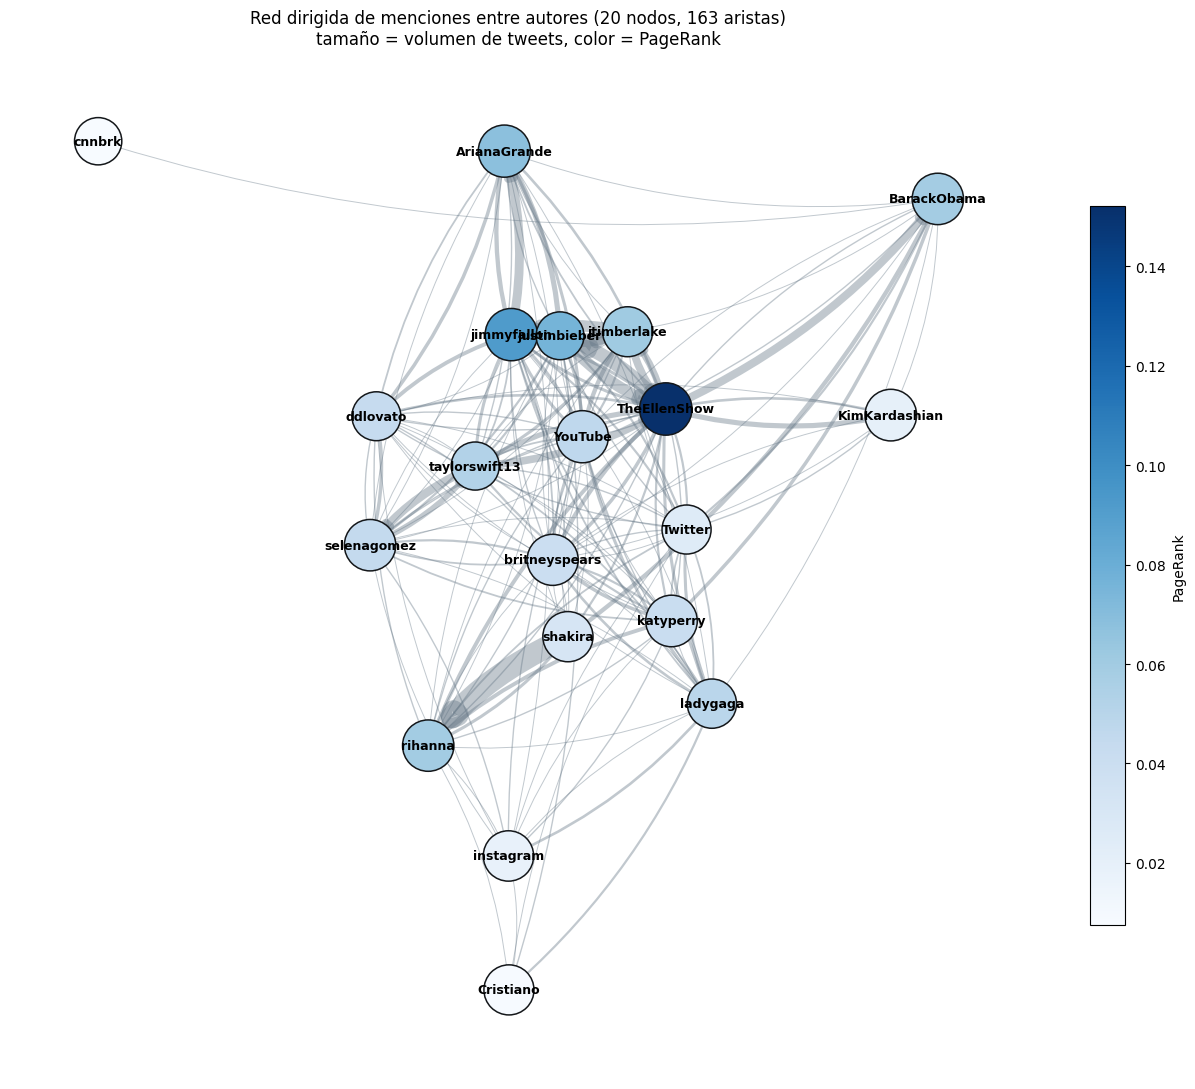

In [43]:
pos = nx.spring_layout(G, weight="weight", seed=11, k=1.6, iterations=500)

tweets_por_autor = df_clean["author"].value_counts()
node_sizes = [300 + 20 * np.sqrt(tweets_por_autor[n]) for n in G.nodes()]
node_colors = [pagerank[n] for n in G.nodes()]
edge_widths = [0.4 + 0.3 * G[u][v]["weight"] for u, v in G.edges()]

fig, ax = plt.subplots(figsize=(13, 11))
nx.draw_networkx_edges(
    G, pos, width=edge_widths, edge_color="#657786", alpha=0.4,
    arrows=True, arrowsize=10, arrowstyle="-|>", connectionstyle="arc3,rad=0.12", ax=ax,
)
nodos = nx.draw_networkx_nodes(
    G, pos, node_color=node_colors, node_size=node_sizes,
    cmap="Blues", edgecolors="#14171A", linewidths=1.1, ax=ax,
)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold", ax=ax)
plt.colorbar(nodos, ax=ax, label="PageRank", shrink=0.7)
titulo = (
    f"Red dirigida de menciones entre autores ({G.number_of_nodes()} nodos, "
    f"{G.number_of_edges()} aristas)\n"
    "tamaño = volumen de tweets, color = PageRank"
)
ax.set_title(titulo)
ax.axis("off")
plt.tight_layout()
plt.savefig("red_dirigida_menciones.png", dpi=150, bbox_inches="tight")
plt.show()

La red dirigida quedó formada por 20 nodos y 163 aristas (menciones entre las 20 cuentas), con una densidad de 0.43 sobre las 380 direcciones posibles y una reciprocidad global de 0.64: la mayoría de las cuentas interactúa en ambos sentidos, típico de un grupo de celebridades/medios que se citan mutuamente. La red es débilmente conexa pero no fuertemente conexa.

TheEllenShow es, con diferencia, la cuenta más activa en ambos sentidos: mayor in_peso (100 menciones recibidas) y mayor out_peso (132 menciones realizadas), y también el PageRank más alto (0.152). jimmyfallon la sigue en ambos frentes. Los pares jimmyfallon-jtimberlake y TheEllenShow-justinbieber son las relaciones recíprocas más fuertes (26 menciones en cada sentido), coherente con colaboraciones o segmentos conjuntos.

El análisis HITS muestra un matiz que el PageRank no capta: shakira es el segundo mejor hub (0.157) porque concentra 52 de sus 68 menciones salientes en una sola cuenta, rihanna, que a su vez resulta ser la authority más alta de toda la red (0.151) pese a tener un in_peso moderado (80). Es decir, shakira actúa como amplificadora de rihanna, más que como un nodo mencionado por muchos.

En conjunto, la red dirigida confirma la agrupación entre cuentas de entretenimiento (TheEllenShow, jimmyfallon, jtimberlake, justinbieber) y aporta evidencia directa (menciones reales, no similitud indirecta) de quién concentra la influencia y quién actúa como amplificador dentro del grupo.